In [1]:
#uncomment and run this if need be
#!pip install -r ../requirements.txt


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
# === PATH CONFIG (Scenario 2 Artifact) ===

# Base folder (relative to notebook)
BASE_DIR = ".."

# Per-user CSVs
PER_USER_DIR = os.path.join(BASE_DIR, "Per_user_csv")

# File paths
OPENAI_PATH   = os.path.join(PER_USER_DIR, "offline_rank_per_user_safe_openai.csv")
LLAMA_PATH    = os.path.join(PER_USER_DIR, "offline_rank_per_user_safe_llama.csv")
CLAUDE_PATH   = os.path.join(PER_USER_DIR, "offline_rank_per_user_safe_claude.csv")
GEMINI_PATH   = os.path.join(PER_USER_DIR, "offline_rank_per_user_safe_gemini.csv")
DEEPSEEK_PATH = os.path.join(PER_USER_DIR, "offline_rank_per_user_safe_deepseek.csv")
TARGUESS_PATH = os.path.join(PER_USER_DIR, "targuess_rank_per_user_safe.csv")

# Bundle for easy use
MODEL_PATHS = {
    "GPT-5.4": OPENAI_PATH,
    "LLaMA-3.3-70B": LLAMA_PATH,
    "Claude Sonnet 4.6": CLAUDE_PATH,
    "Gemini 2.5 Pro": GEMINI_PATH,
    "DeepSeek-Chat": DEEPSEEK_PATH,
    "TarGuess-style": TARGUESS_PATH,
}

# Quick check
for name, path in MODEL_PATHS.items():
    print(f"{name}: {'OK' if os.path.exists(path) else 'Missing'} → {path}")

GPT-5.4: OK → ..\Per_user_csv\offline_rank_per_user_safe_openai.csv
LLaMA-3.3-70B: OK → ..\Per_user_csv\offline_rank_per_user_safe_llama.csv
Claude Sonnet 4.6: OK → ..\Per_user_csv\offline_rank_per_user_safe_claude.csv
Gemini 2.5 Pro: OK → ..\Per_user_csv\offline_rank_per_user_safe_gemini.csv
DeepSeek-Chat: OK → ..\Per_user_csv\offline_rank_per_user_safe_deepseek.csv
TarGuess-style: OK → ..\Per_user_csv\targuess_rank_per_user_safe.csv


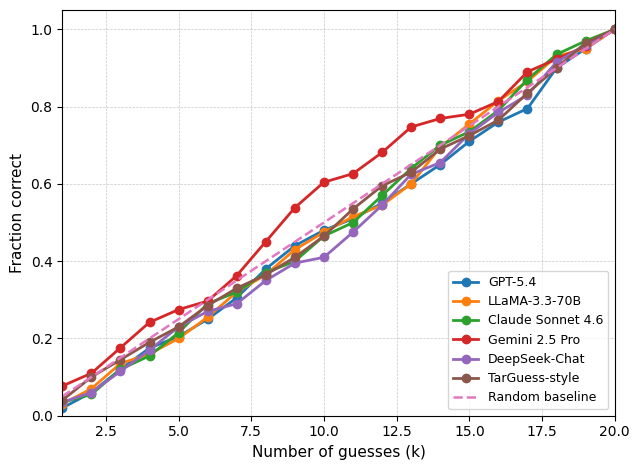

In [4]:
ks = np.arange(1, 21)

plt.figure(figsize=(6.5, 4.8))

for label, path in MODEL_PATHS.items():
    if not os.path.exists(path):
        print("Missing:", path)
        continue

    df = pd.read_csv(path)

    ranks = df["rank_of_true"].astype(float).values
    pgc = [(ranks <= k).mean() for k in ks]

    plt.plot(ks, pgc, marker="o", linewidth=2.0, label=label)

# Random baseline
plt.plot(ks, ks / 20.0, linestyle="--", linewidth=1.8, label="Random baseline")

# Labels
plt.xlabel("Number of guesses (k)", fontsize=11)
plt.ylabel("Fraction correct", fontsize=11)

# Formatting
plt.xlim(1, 20)
plt.ylim(0, 1.05)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend(fontsize=9, loc="lower right", frameon=True)
plt.tight_layout()

plt.show()

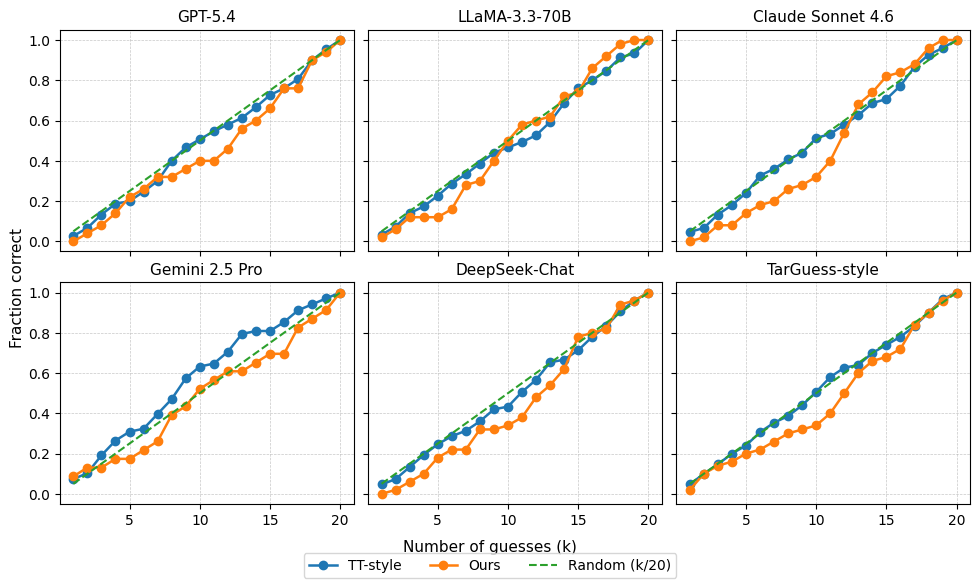

In [5]:
ks = np.arange(1, 21)

fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (title, path) in zip(axes, MODEL_PATHS.items()):
    if not os.path.exists(path):
        ax.set_title(f"{title}\nMissing file", fontsize=11)
        ax.axis("off")
        continue

    df = pd.read_csv(path)

    # Optional filter (keep if present)
    if "tp" in df.columns:
        df = df[df["tp"].astype(float) == 0.1].copy()

    if "condition" in df.columns:
        df_tt = df[df["condition"] == "paper"].copy()
        df_ours = df[df["condition"] == "yours"].copy()

        if len(df_tt) > 0:
            ranks_tt = df_tt["rank_of_true"].astype(float).values
            pgc_tt = [(ranks_tt <= k).mean() for k in ks]
            ax.plot(ks, pgc_tt, marker="o", linewidth=1.8, label="TT-style")

        if len(df_ours) > 0:
            ranks_ours = df_ours["rank_of_true"].astype(float).values
            pgc_ours = [(ranks_ours <= k).mean() for k in ks]
            ax.plot(ks, pgc_ours, marker="o", linewidth=1.8, label="Ours")
    else:
        # fallback (no condition column)
        ranks = df["rank_of_true"].astype(float).values
        pgc = [(ranks <= k).mean() for k in ks]
        ax.plot(ks, pgc, marker="o", linewidth=1.8, label="Model")

    # Random baseline
    ax.plot(ks, ks / 20.0, linestyle="--", linewidth=1.5, label="Random (k/20)")

    ax.set_title(title, fontsize=11)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    ax.tick_params(axis="both", labelsize=10)

# labels
fig.text(0.5, 0.06, "Number of guesses (k)", ha="center", fontsize=11)
fig.text(0.02, 0.5, "Fraction correct", va="center", rotation="vertical", fontsize=11)

# legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=True, fontsize=10, bbox_to_anchor=(0.5, 0.005))

fig.subplots_adjust(left=0.07, right=0.98, top=0.93, bottom=0.14, wspace=0.05, hspace=0.14)

plt.show()